#Rock🪨 Paper📄 Scisors✂️

##Constants and Imports

In [344]:
import random
import matplotlib.pyplot as plt

moves = ["🪨","📄","✂️"]
winning_moves = {"🪨":"✂️","📄":"🪨","✂️":"📄"}

##Generates a transition matrix (Markov chain) for Player 1.


In [345]:
p1_matrix = {}
for i in range(3):
  rock = random.uniform(0,1)
  paper = random.uniform(0,1-rock)
  scisors = 1-rock-paper
  p1_matrix[moves[i]] = {"🪨":rock,"📄":paper,"✂️":scisors}

# print("Player1 transition matrix")
# print(player1)
print("Move matrix of Player 1:")
for key, value in p1_matrix.items():
  print(f"{key}:", end=" ")
  for key2, value2 in value.items():
    print(f"{key2}: {value2/sum(value.values())*100:.2f}%",end=" ")
  print()

Move matrix of Player 1:
🪨: 🪨: 17.97% 📄: 77.22% ✂️: 4.81% 
📄: 🪨: 92.60% 📄: 4.72% ✂️: 2.68% 
✂️: 🪨: 72.82% 📄: 14.11% ✂️: 13.07% 


##Initializes Player 2's memory (occurrence counter of Player 1's moves)

In [346]:
occurances = {m1: {m2: 1 for m2 in moves} for m1 in moves}
print("Player2 memory")
for key, value in occurances.items():
  print(f"{key}: {value}")

Player2 memory
🪨: {'🪨': 1, '📄': 1, '✂️': 1}
📄: {'🪨': 1, '📄': 1, '✂️': 1}
✂️: {'🪨': 1, '📄': 1, '✂️': 1}


##Simulates the game for a specified number of rounds

In [347]:
# Initialize score counters
wins1,wins2,all_draws = 0, 0, 0
p1_history,p2_history,draw_history = [],[],[]

# Random initial moves (zero state)
move1 = random.choice(moves)
move2 = random.choice(moves)
last_move = random.choice(moves)

for i in range (1000):
  if move1 != move2:
    if winning_moves[move1] == move2:
      wins1 += 1
    else:
      wins2 += 1
  else:
    all_draws += 1
  occurances[last_move][move1] += 1
  last_move = move1
  # Player 1 chooses a move based on their transition matrix and last move
  move1 = random.choices(moves,weights=[p1_matrix[move1][m] for m in moves])[0]

  # Player 2 chooses a counter-move based on memory of Player 1's behavior
  # Weight for move 'm' = frequency of the move that 'm' beats
  weights2 = [occurances[last_move][winning_moves[m]] for m in moves]
  move2 = random.choices(moves,weights=weights2)[0]
  p1_history.append(wins1)
  p2_history.append(wins2)
  draw_history.append(all_draws)

print(f"Player 1 wins: {wins1} times")
print(f"Player 2 wins: {wins2} times")
print("Move matrix of Player 2:")
for key, value in occurances.items():
  print(f"{key}:", end=" ")
  for key2, value2 in value.items():
    print(f"{winning_moves[winning_moves[key2]]}: {value2/sum(value.values())*100:.2f}%",end=" ")
  print()


Player 1 wins: 161 times
Player 2 wins: 677 times
Move matrix of Player 2:
🪨: 📄: 21.01% ✂️: 72.61% 🪨: 6.38% 
📄: 📄: 91.45% ✂️: 5.46% 🪨: 3.09% 
✂️: 📄: 67.27% ✂️: 20.00% 🪨: 12.73% 


##Figure

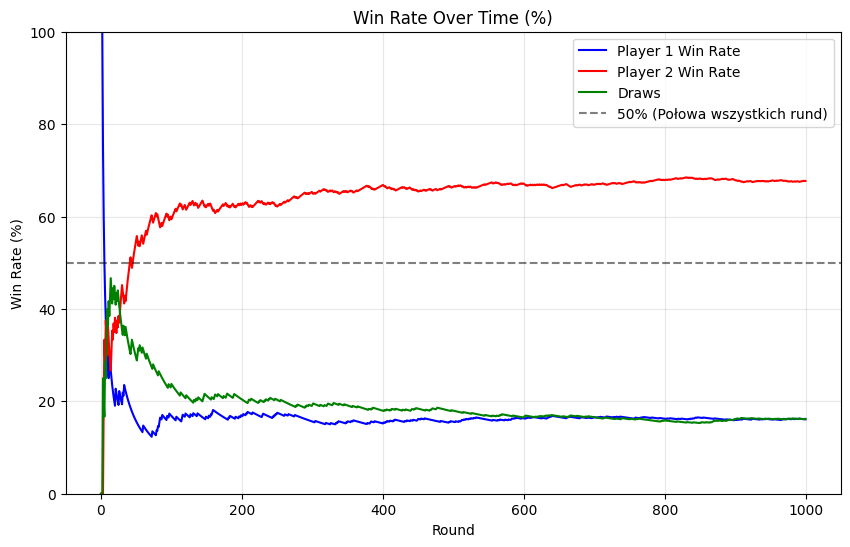

In [348]:
# Calculating the precentege of each state
p1_win_rate = [(wins / (i + 1)) * 100 for i, wins in enumerate(p1_history)]
p2_win_rate = [(wins / (i + 1)) * 100 for i, wins in enumerate(p2_history)]
draw_rate = [(draws / (i + 1)) * 100 for i, draws in enumerate(draw_history)]

plt.figure(figsize=(10, 6))

plt.plot(p1_win_rate, label='Player 1 Win Rate', color='blue')
plt.plot(p2_win_rate, label='Player 2 Win Rate', color='red')
plt.plot(draw_rate, label='Draws', color='green')


# 50% line
plt.axhline(50, color='black', linestyle='--', alpha=0.5, label='50% (Połowa wszystkich rund)')

plt.title('Win Rate Over Time (%)')
plt.xlabel('Round')
plt.ylabel('Win Rate (%)')

# Normalization of OY
plt.ylim(0, 100)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()